# Customer Churn Analysis — Exploratory Data Analysis

**Objective:** Explore customer data to understand the key drivers of churn and surface actionable insights that could support a retention strategy.

**Structure of this notebook:**
1. **Part 1 — Warm-up EDA** on a bank customer dataset (`Churn_Modelling.csv`) to practice univariate/bivariate analysis and correlation techniques.
2. **Part 2 — Case Study** on a telecom customer dataset (`CustomerChurn.csv`): data cleaning, feature binning, univariate/bivariate analysis, and a final set of business-relevant insights.

**Datasets:**
- `Churn_Modelling.csv` — bank customer churn dataset (place in a local `data/` folder).
- `CustomerChurn.csv` — IBM/Telco-style customer churn dataset (place in a local `data/` folder).

**Tools used:** Python, Pandas, NumPy, Matplotlib, Seaborn.


In [1]:
# import the required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
telcom_data = pd.read_csv('data/Churn_Modelling.csv')


In [3]:
telcom_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
telcom_new = telcom_data[['Geography' , 'Gender' , 'Exited']]
telcom_new.head()

,Geography,Gender,Exited
0,France,Female,1
1,Spain,Female,0
2,France,Female,1
3,France,Female,0
4,Spain,Female,0


## Part 1: Warm-up EDA (Bank Customer Churn Dataset)


### **Univariate Analysis**

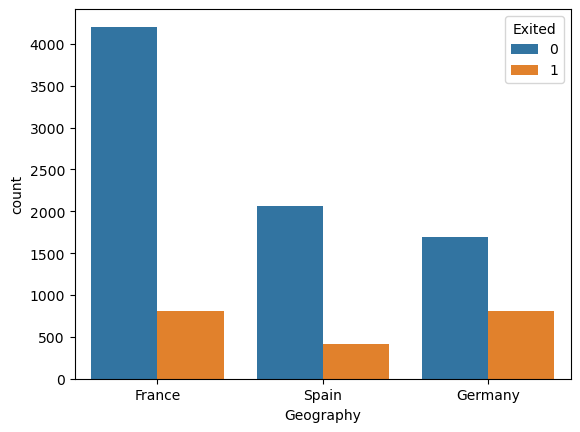

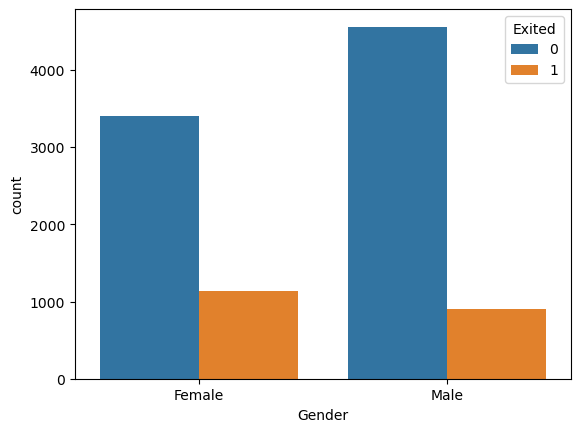

In [5]:
for i, predictor in enumerate(telcom_new.drop(columns=['Exited'])):
  plt.figure()
  sns.countplot(data=telcom_new , x=predictor , hue='Exited')

In [6]:
telcom_new.Exited.value_counts()/len(telcom_new)*100

Exited
0    79.63
1    20.37
Name: count, dtype: float64

# **Bivariate analysis**

<Axes: xlabel='Gender', ylabel='Count'>

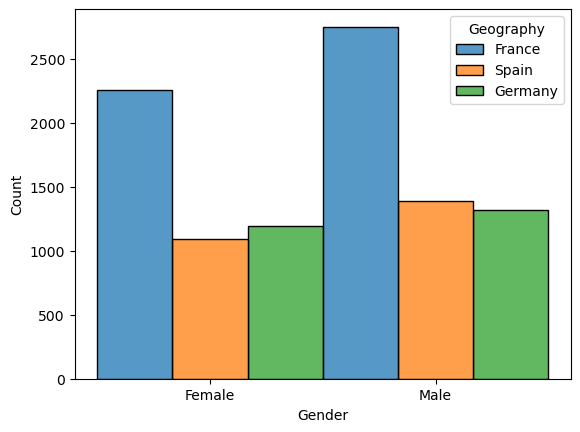

In [7]:
sns.histplot(x='Gender', hue = 'Geography',data=telcom_new, stat="count", multiple="dodge")

In [8]:
telcom_new_target1 = telcom_new.loc[telcom_new["Exited"]==1]

<Axes: xlabel='Gender', ylabel='Count'>

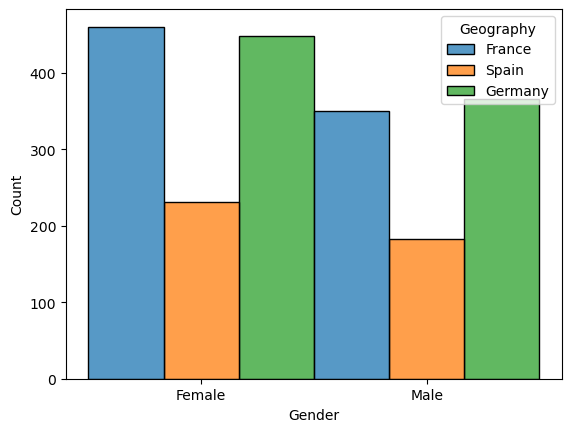

In [9]:
sns.histplot(x='Gender', hue = 'Geography',data=telcom_new_target1, stat="count", multiple="dodge")

# **Numerical Analysis**
- Correlation : It ranges from -1 to 1
-  1 --> Positive Correlation
-  -1 --> Negative correlation
-  0 --> No Correlation

In [10]:
telcom_data.select_dtypes(include=np.number).corr()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,1.000000,0.004202,0.005840,0.000783,-0.006495,-0.009067,0.007246,0.000599,0.012044,-0.005988,-0.016571
CustomerId,0.004202,1.000000,0.005308,0.009497,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248
CreditScore,0.005840,0.005308,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
Age,0.000783,0.009497,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
Tenure,-0.006495,-0.014883,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
Balance,-0.009067,-0.012419,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
NumOfProducts,0.007246,0.016972,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
HasCrCard,0.000599,-0.014025,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
IsActiveMember,0.012044,0.001665,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
EstimatedSalary,-0.005988,0.015271,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097


<Axes: >

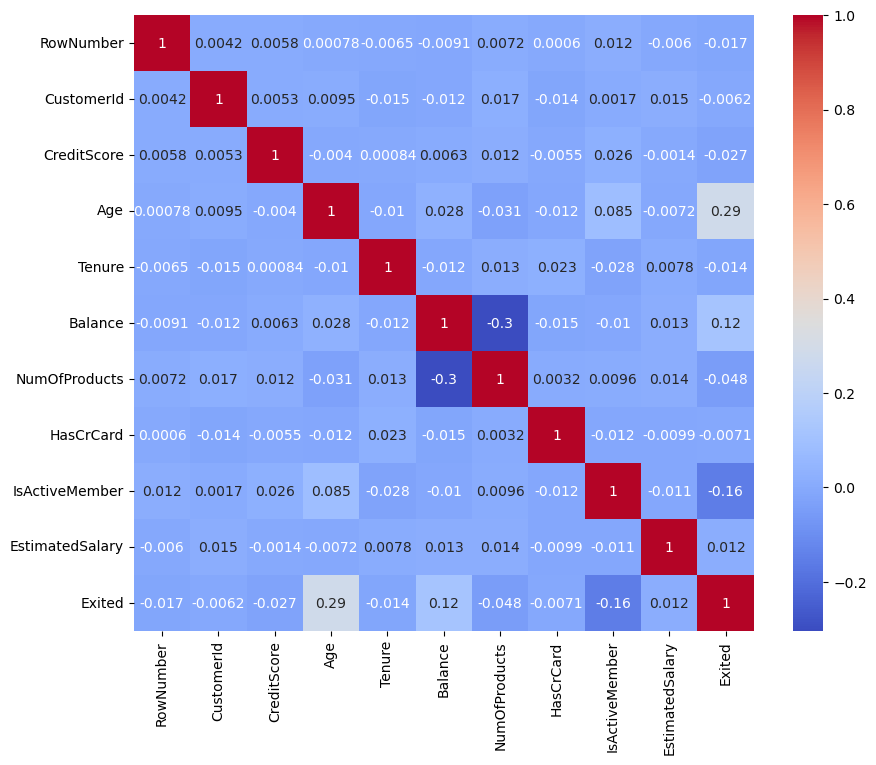

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(telcom_data.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')

<Axes: >

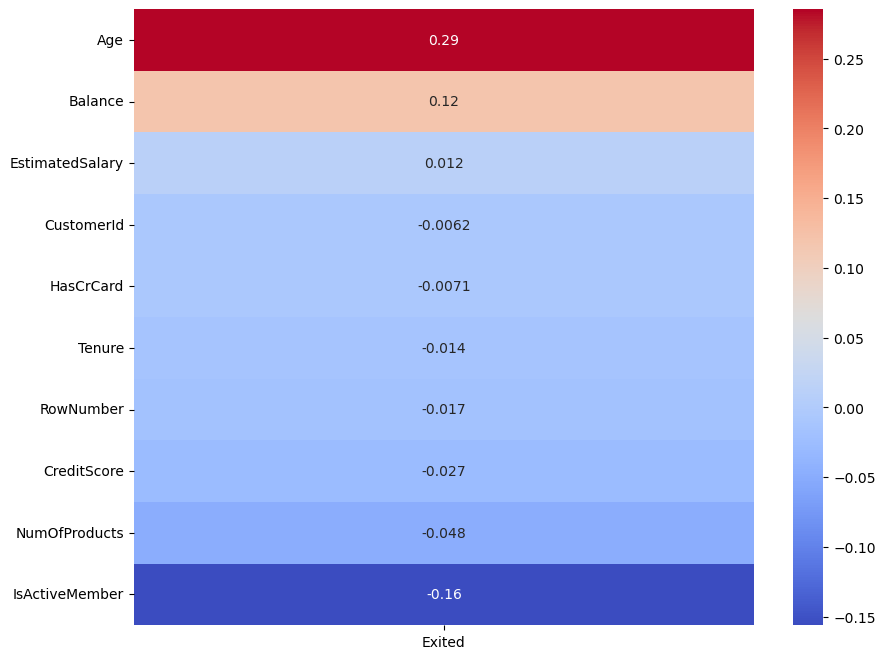

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(telcom_data.select_dtypes(include=np.number).corr()['Exited'].sort_values(ascending=False)[1:].to_frame(), annot=True, cmap='coolwarm')

<Axes: >

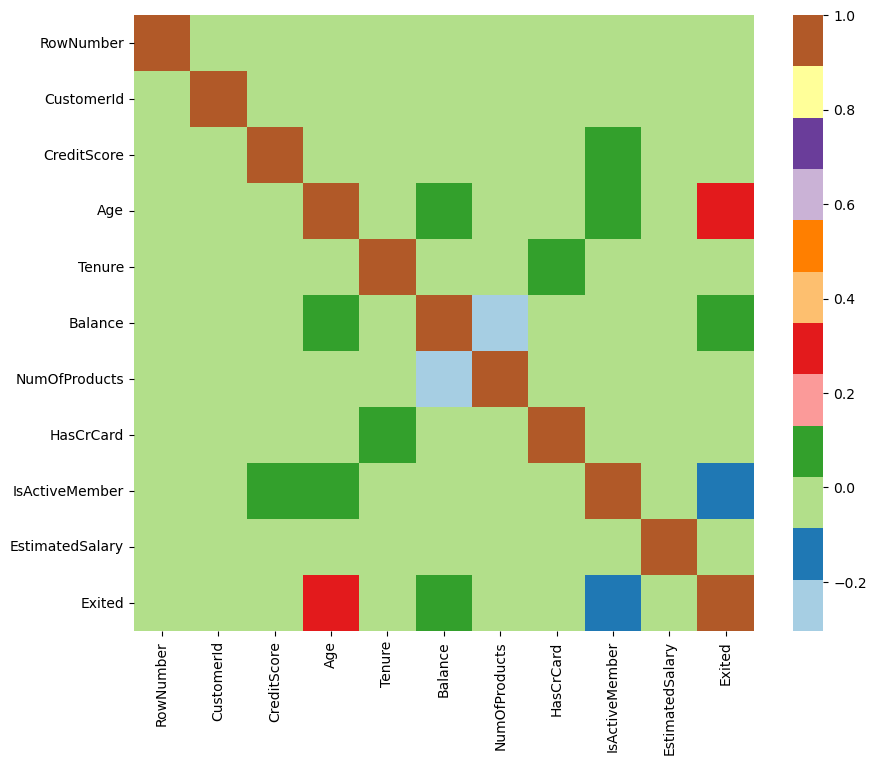

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(telcom_data.select_dtypes(include=np.number).corr(),cmap='Paired')

<Axes: xlabel='Age'>

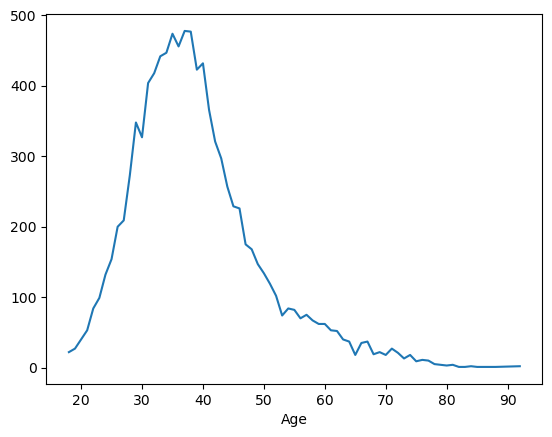

In [14]:
telcom_data['Age'].value_counts().sort_index().plot()

<Axes: xlabel='Age'>

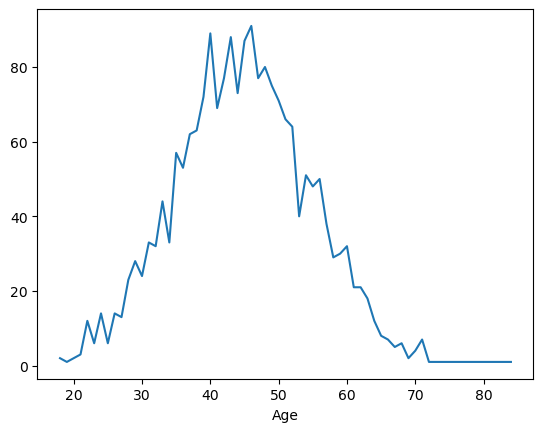

In [15]:
telcom_data_1 = telcom_data.loc[telcom_data['Exited']==1]
telcom_data_1['Age'].value_counts().sort_index(ascending=True).plot()

Text(0.5, 1.0, 'Age vs Exited')

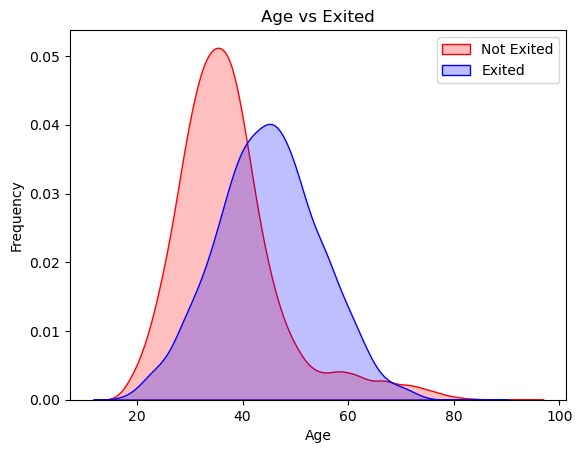

In [16]:
Tot = sns.kdeplot(telcom_data.Age[(telcom_data["Exited"]==0)],
                  color="Red", fill = True, label = "Not Exited")
Not = sns.kdeplot(telcom_data.Age[(telcom_data["Exited"]==1)],
                  color="Blue", fill = True,label = "Exited")
Tot.legend(["Not Exited","Exited"])
Tot.set_xlabel("Age")
Tot.set_ylabel("Frequency")
Tot.set_title("Age vs Exited")

Text(0.5, 1.0, 'Tenure vs Exited')

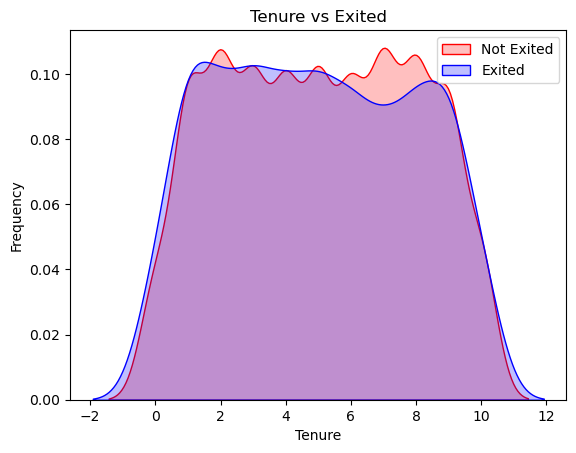

In [17]:
Tot = sns.kdeplot(telcom_data.Tenure[(telcom_data["Exited"]==0)],
                  color="Red", fill = True, label = "Not Exited")
Not = sns.kdeplot(telcom_data.Tenure[(telcom_data["Exited"]==1)],
                  color="Blue", fill = True,label = "Exited")
Tot.legend(["Not Exited","Exited"],loc='upper right')
Tot.set_xlabel("Tenure")
Tot.set_ylabel("Frequency")
Tot.set_title("Tenure vs Exited")

Text(0.5, 1.0, 'Balance vs Exited')

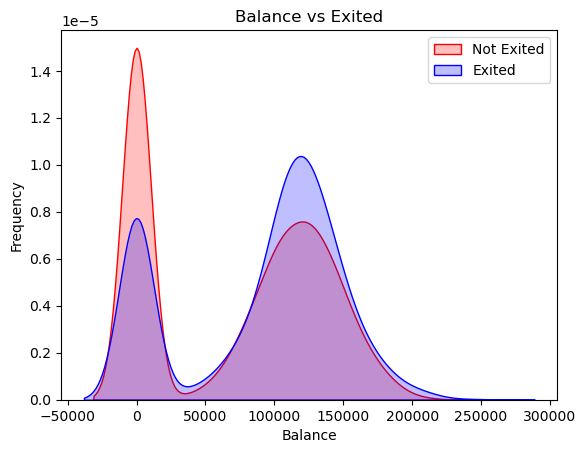

In [18]:
Tot = sns.kdeplot(telcom_data.Balance[(telcom_data["Exited"]==0)],
                  color="Red", fill = True, label = "Not Exited")
Not = sns.kdeplot(telcom_data.Balance[(telcom_data["Exited"]==1)],
                  color="Blue", fill = True,label = "Exited")
Tot.legend(["Not Exited","Exited"],loc='upper right')
Tot.set_xlabel("Balance")
Tot.set_ylabel("Frequency")
Tot.set_title("Balance vs Exited")

# **Feature Binning**

In [19]:
telcom_data.drop(columns=['CustomerId','RowNumber','Surname'],axis=1,inplace=True)

In [20]:
telcom_data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [21]:
telcom_data.Age.min()

18

In [22]:
telcom_data.Age.max()

92

In [23]:
labels = ['0-20','21-40','41-60','Above 61']
bins = [0,20,40,60,100]
telcom_data['Age_bin'] = pd.cut(telcom_data.Age,
bins=bins,labels=labels,include_lowest=True)

In [24]:
telcom_data[['Age','Age_bin']]

,Age,Age_bin
0,42,41-60
1,41,41-60
2,42,41-60
3,39,21-40
4,43,41-60
...,...,...
9995,39,21-40
9996,35,21-40
9997,36,21-40
9998,42,41-60


In [25]:
telcom_data.Age_bin.value_counts()

Age_bin
21-40       6330
41-60       3117
Above 61     464
0-20          89
Name: count, dtype: int64

In [26]:
def add_labels(x,y):
  for i in range(len(x)):
    plt.text(i,y[i],y[i],ha='center',va='bottom')

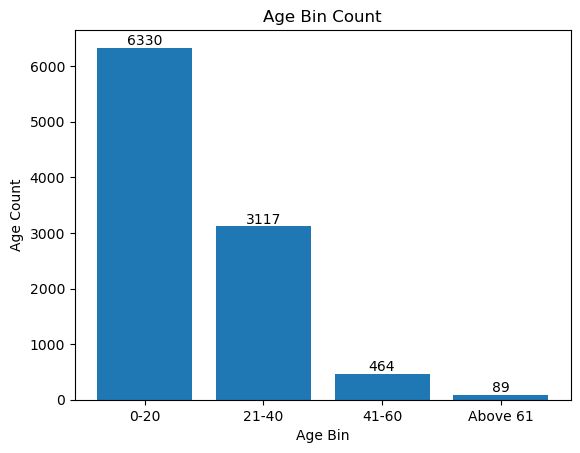

In [27]:
# Visualizing a bar chart on the above Data
plt.bar(labels,telcom_data.Age_bin.value_counts())
add_labels(labels,telcom_data.Age_bin.value_counts())
plt.title('Age Bin Count')
plt.xlabel('Age Bin')
plt.ylabel('Age Count')
plt.show()

## Part 2: Case Study — Telecom Customer Churn Analysis

# **CASE STUDY : CUSTOMER CHURN ANALYSIS**

**Dataset Info** : Sample Data Set containing customer data and showing customers who left last month

In [28]:
df = pd.read_csv('data/CustomerChurn.csv')


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [30]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [31]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


- SeniorCitizen is actually a categorical hence the 25% - 50% & 75% distribution is not proper
- 75% customers have tenure less than 55 months
- Average monthly charges are USD 64.76 whereas 25% customers pay more than USD 89.85 per month

In [32]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [33]:
df['Churn'].value_counts()/len(df)*100

Churn
No     73.463013
Yes    26.536987
Name: count, dtype: float64

Text(0.5, 1.0, 'Count of Target Variable per Class')

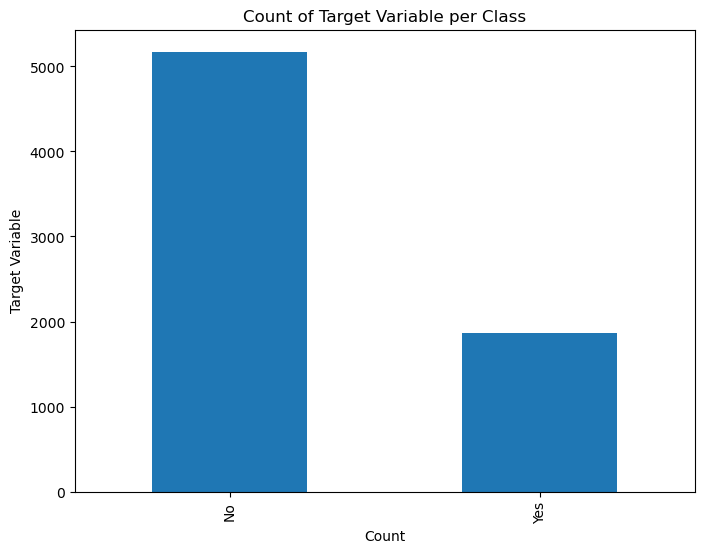

In [34]:
df['Churn'].value_counts().plot(kind='bar',figsize=(8,6))
plt.xlabel('Count')
plt.ylabel('Target Variable')
plt.title('Count of Target Variable per Class')

In [35]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

- Data is highly imbalanced , ratio = ~73% : 27%
- So we analyse the data with other features while taking the target values separately to get some insights.


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


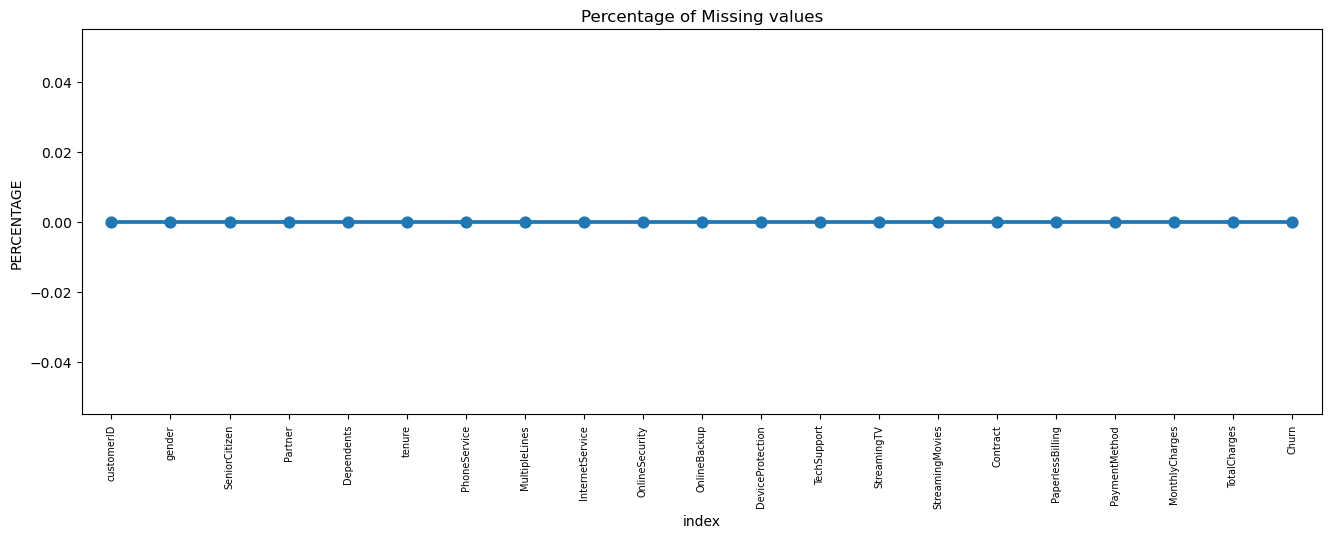

In [37]:
# Generic code for finding missing values
missing = pd.DataFrame((df.isnull().sum())*100/df.shape[0]).reset_index()
plt.figure(figsize=(16,5))
ax = sns.pointplot(x='index',y=0,data=missing)
plt.xticks(rotation =90,fontsize =7)
plt.title("Percentage of Missing values")
plt.ylabel("PERCENTAGE")
plt.show()

**Missing Data - Initial Intuition**
- Here , we don't have any missing data.

General Thumb Rules:

- For features with less missing values- can use regression to predict the missing values or fill with the mean of the values present, depending on the feature.
- For features with very high number of missing values- It is better to drop those columns as they give very less insight on analysis.
- As there's no thumb rule on what criteria do we delete the columns with high number of missing values, but generally you can delete the columns, if you have more than 30-40% of missing values. But again there's catch here, for example, Is_car & Car_Type, People having no cars ,will obviously have Car_Type as NaN(null), but that doesn't make this column useless,so decisions has to be taken wisely.

# **Data Cleaning**

**1**. Create a copy of base data for manipulation & processing

In [38]:
new_df = df.copy()


In [39]:
new_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**2**. Total Charges should be numeric amount. Let's convert it to numerical data type

In [40]:
new_df.TotalCharges = pd.to_numeric(new_df.TotalCharges,errors='coerce')
new_df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [41]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**3**. As we can see there are 11 missing values in TotalCharges column. Let's check these records


In [42]:
new_df.loc[new_df.TotalCharges.isnull()==True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


**4. Missing Value Treatment**

Since the % of these records compared to total dataset is very low i.e 0.15%. It is safe to ignore them from further processing.

In [43]:
#Removing missing values
new_df.dropna(how='any',inplace=True)

**5**. Divide customers into bins based on tenure e.g for tenure < 12 months: assign a tenure group if 1-12, for tenure between 1 to 2 Yrs, tenure group of 13-24 and so on

In [44]:
# Get the max tenure
print(new_df.tenure.max())
#print(new_df['tenure'].max())

72


In [45]:
labels = ["{0} - {1}".format(i,i+11) for i in range(1,72,12)]
print( labels)

['1 - 12', '13 - 24', '25 - 36', '37 - 48', '49 - 60', '61 - 72']


In [46]:
# Group the tenure in bins of 12 months
labels = ["{0} - {1}".format(i,i+11) for i in range(1,72,12)]

new_df['tenure_group'] = pd.cut(new_df.tenure,range(1,80,12),labels=labels)

In [47]:
new_df['tenure_group'].value_counts()

tenure_group
1 - 12     1671
61 - 72    1331
13 - 24     994
49 - 60     842
25 - 36     818
37 - 48     763
Name: count, dtype: int64

**6**. Remove columns not required for processing

In [48]:
# drop column customerID and tunure
new_df.drop(columns=['customerID','tenure'],axis=1,inplace=True)
new_df

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,NaN
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1 - 12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,13 - 24
7039,Female,0,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,61 - 72
7040,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,1 - 12
7041,Male,1,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,1 - 12


# **Data Exploration**

- Plot distribution of individual predictors by churn

**Univiriate analysis**

In [49]:
new_df

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,NaN
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1 - 12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,13 - 24
7039,Female,0,Yes,Yes,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,61 - 72
7040,Female,0,Yes,Yes,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,1 - 12
7041,Male,1,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,1 - 12


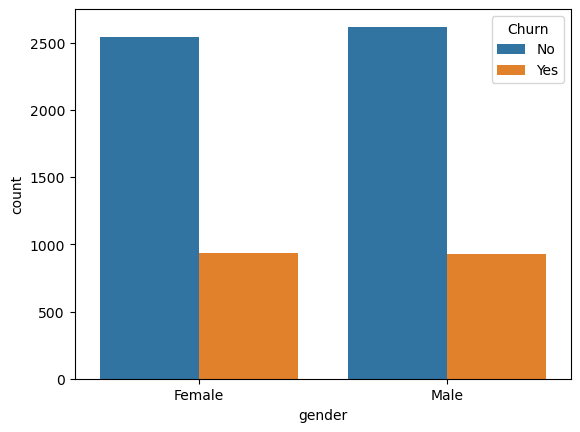

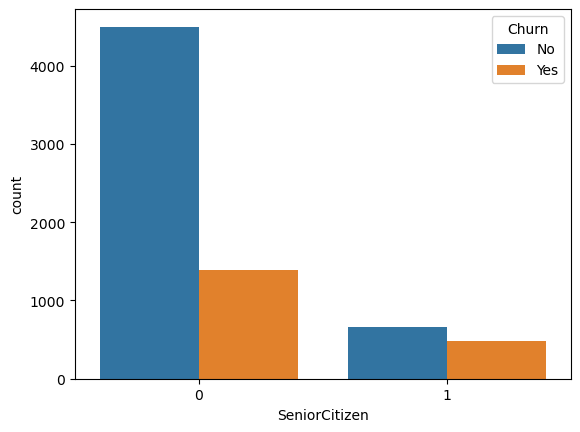

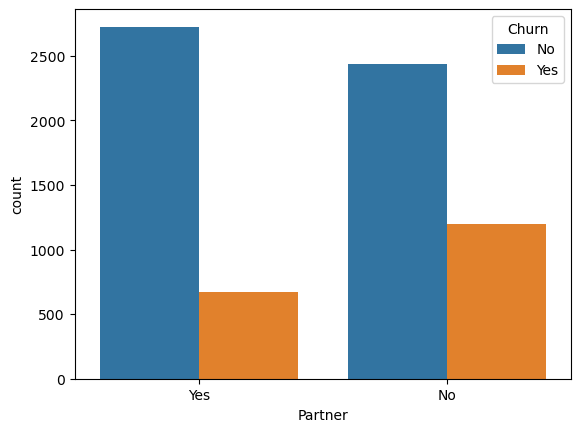

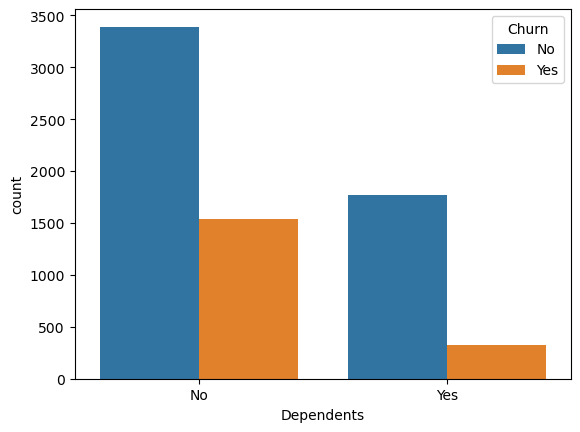

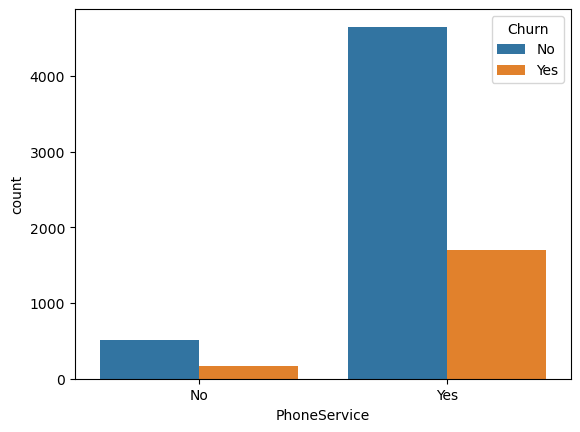

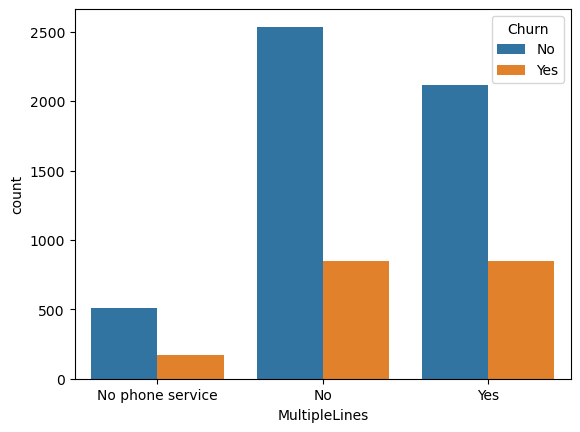

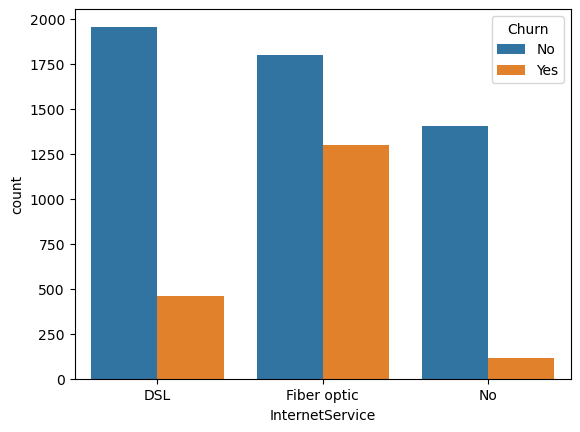

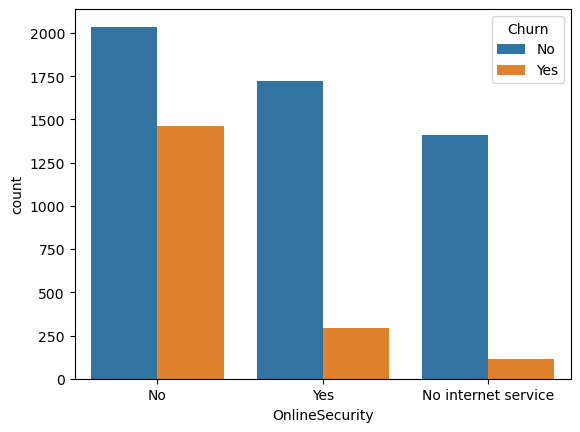

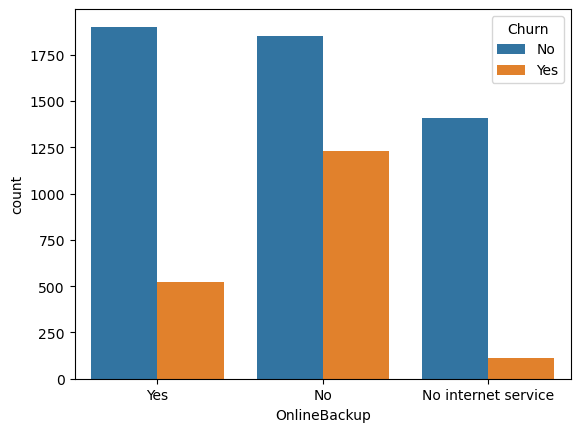

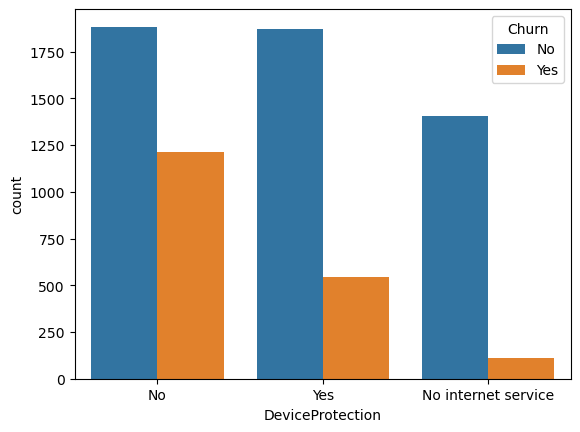

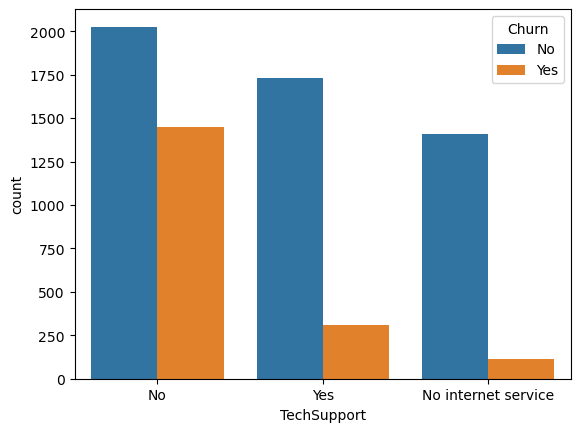

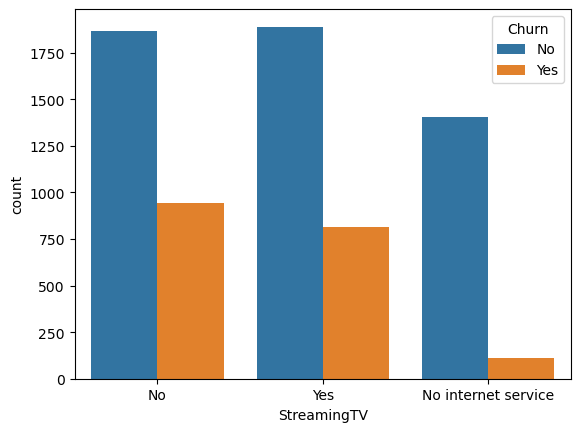

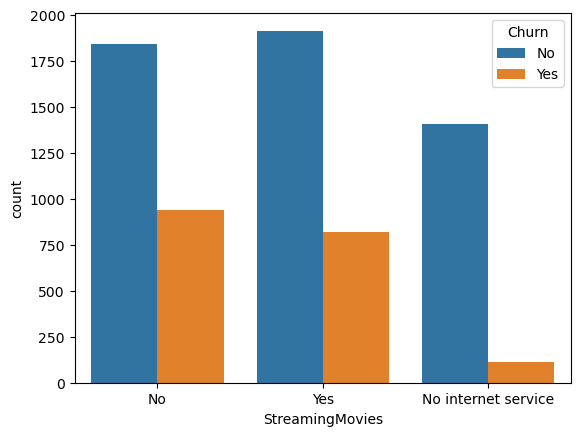

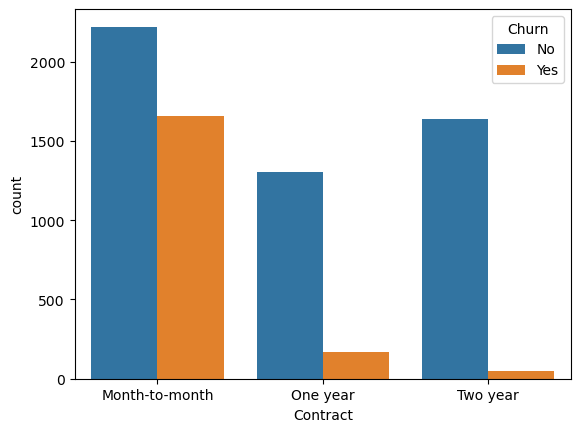

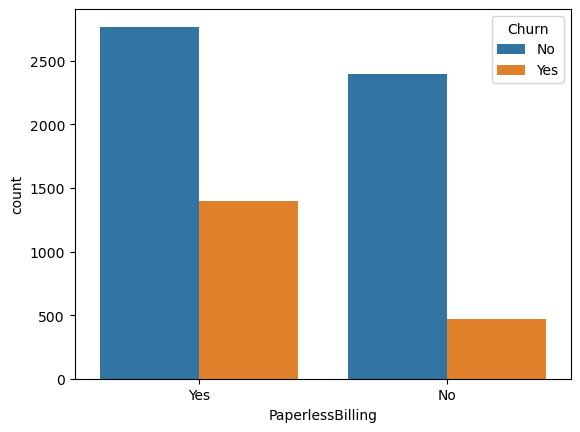

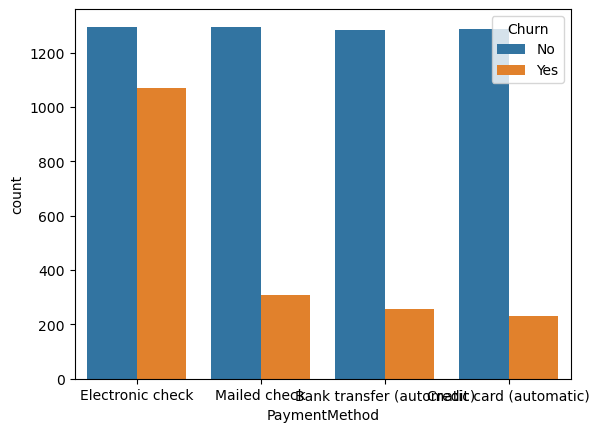

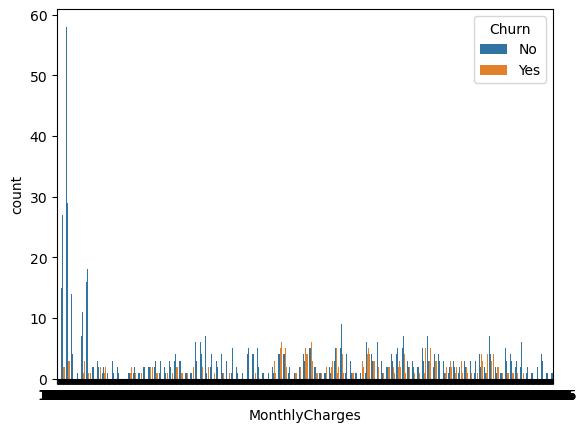

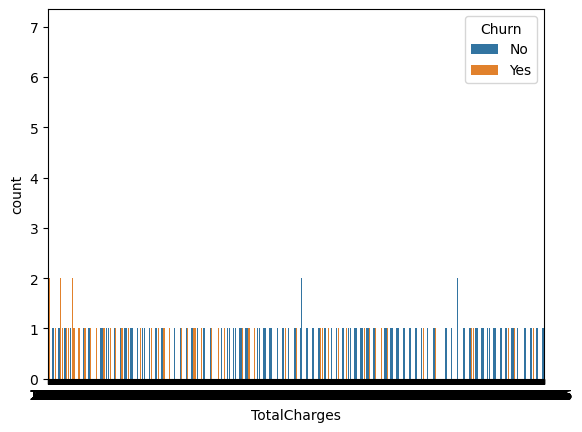

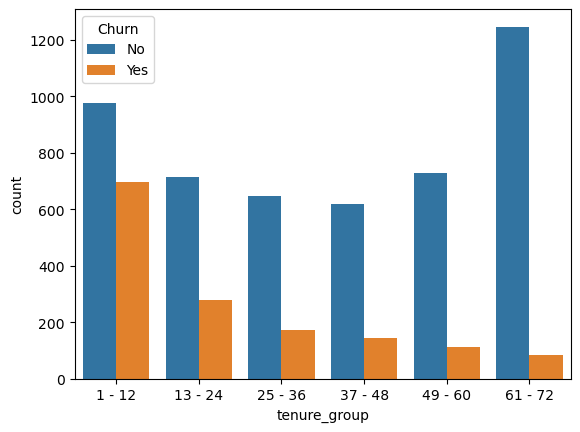

In [50]:
for i,predictor in enumerate(new_df.drop(columns=['Churn'])):
  plt.figure()
  sns.countplot(data=new_df,x=predictor,hue='Churn')

**Numerical Analysis**

In [51]:
new_df.gender.value_counts()

gender
Male      3549
Female    3483
Name: count, dtype: int64

In [52]:
new_df1_target0 = new_df[new_df['Churn']=='No']
new_df1_target1 = new_df[new_df['Churn']=='Yes']

In [53]:
new_df1_target1.gender.value_counts()

gender
Female    939
Male      930
Name: count, dtype: int64

In [54]:
pd.crosstab(new_df.PaymentMethod,new_df.Churn)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


**7**. Convert the target variable 'Churn' in a binary numeric variable i.e Yes = 1 : no = 0


In [55]:
new_df['Churn'] = np.where(new_df.Churn == 'Yes',1,0)

In [56]:
new_df.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,NaN
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25 - 36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1 - 12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37 - 48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1 - 12


**8**. Convert all the categorical variables into dummy variables


In [57]:
new_df_dummies = pd.get_dummies(new_df).astype(int)  # convert boolean dummies to 0/1
display(new_df_dummies.head())


,SeniorCitizen,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1 - 12,tenure_group_13 - 24,tenure_group_25 - 36,tenure_group_37 - 48,tenure_group_49 - 60,tenure_group_61 - 72
0,0,29,29,0,1,0,0,1,1,0,...,0,0,1,0,0,0,0,0,0,0
1,0,56,1889,0,0,1,1,0,1,0,...,0,0,0,1,0,0,1,0,0,0
2,0,53,108,1,0,1,1,0,1,0,...,0,0,0,1,1,0,0,0,0,0
3,0,42,1840,0,0,1,1,0,1,0,...,1,0,0,0,0,0,0,1,0,0
4,0,70,151,1,1,0,1,0,1,0,...,0,0,1,0,1,0,0,0,0,0


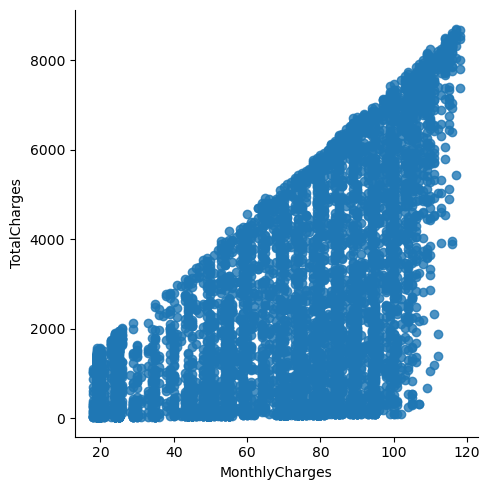

In [58]:
sns.lmplot(data=new_df_dummies,x='MonthlyCharges',y='TotalCharges', fit_reg=False)

In [59]:
new_df_dummies['MonthlyCharges'].corr(new_df_dummies['TotalCharges'])

np.float64(0.6511252380434778)

**9**. Churn by Monthly Charges and Total Charges


Text(0.5, 1.0, 'Monthly Charges vs Churn')

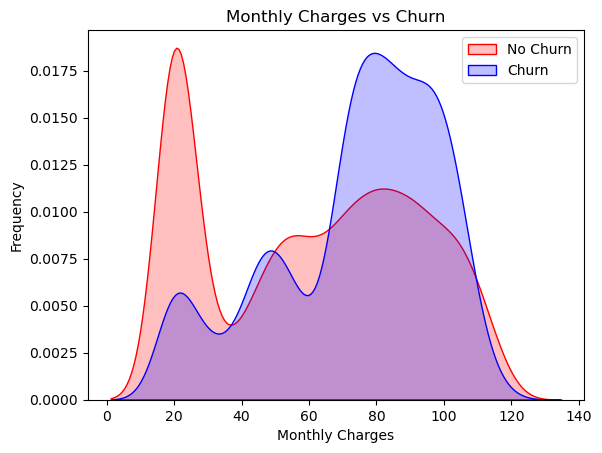

In [60]:
Mth = sns.kdeplot(new_df_dummies.MonthlyCharges[(new_df_dummies["Churn"] == 0)],
                  color="Red", fill = True)
Mth = sns.kdeplot(new_df_dummies.MonthlyCharges[(new_df_dummies["Churn"] == 1)],
                  color="Blue", fill = True)
Mth.legend(["No Churn","Churn"],loc = 'upper right')
Mth.set_xlabel("Monthly Charges")
Mth.set_ylabel("Frequency")
Mth.set_title("Monthly Charges vs Churn")

Text(0.5, 1.0, 'Total Charges vs Churn')

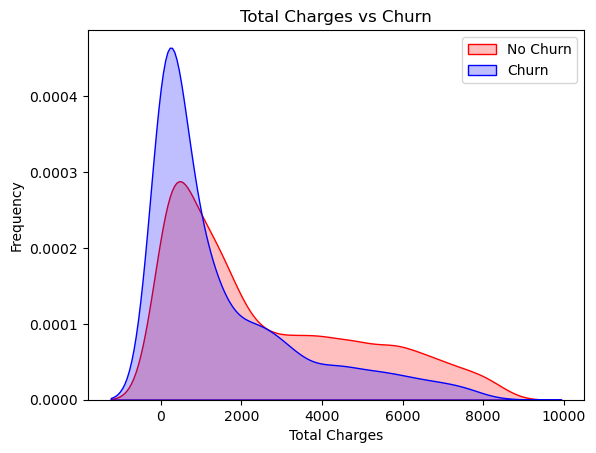

In [61]:
Mth = sns.kdeplot(new_df_dummies.TotalCharges[(new_df_dummies["Churn"] == 0)],
                  color="Red", fill = True)
Mth = sns.kdeplot(new_df_dummies.TotalCharges[(new_df_dummies["Churn"] == 1)],
                  color="Blue", fill = True)
Mth.legend(["No Churn","Churn"],loc = 'upper right')
Mth.set_xlabel("Total Charges")
Mth.set_ylabel("Frequency")
Mth.set_title("Total Charges vs Churn")

**Surprising insight ** as higher churn at lower total charges

However if we combine the insights of 3 parameters i.e Tenure, Monthly Charges & Total Charges then the picture is bit clear : Higher Monthly Charges at lower tenure results into lower total charge.
Hence, all these 3 factors viz **Higher Monthly Charge, Lower tenure** and **Lower Total Charge **
are linked to **High Churn**

**10**. Build a correlation of all predictors with Churn


<Axes: >

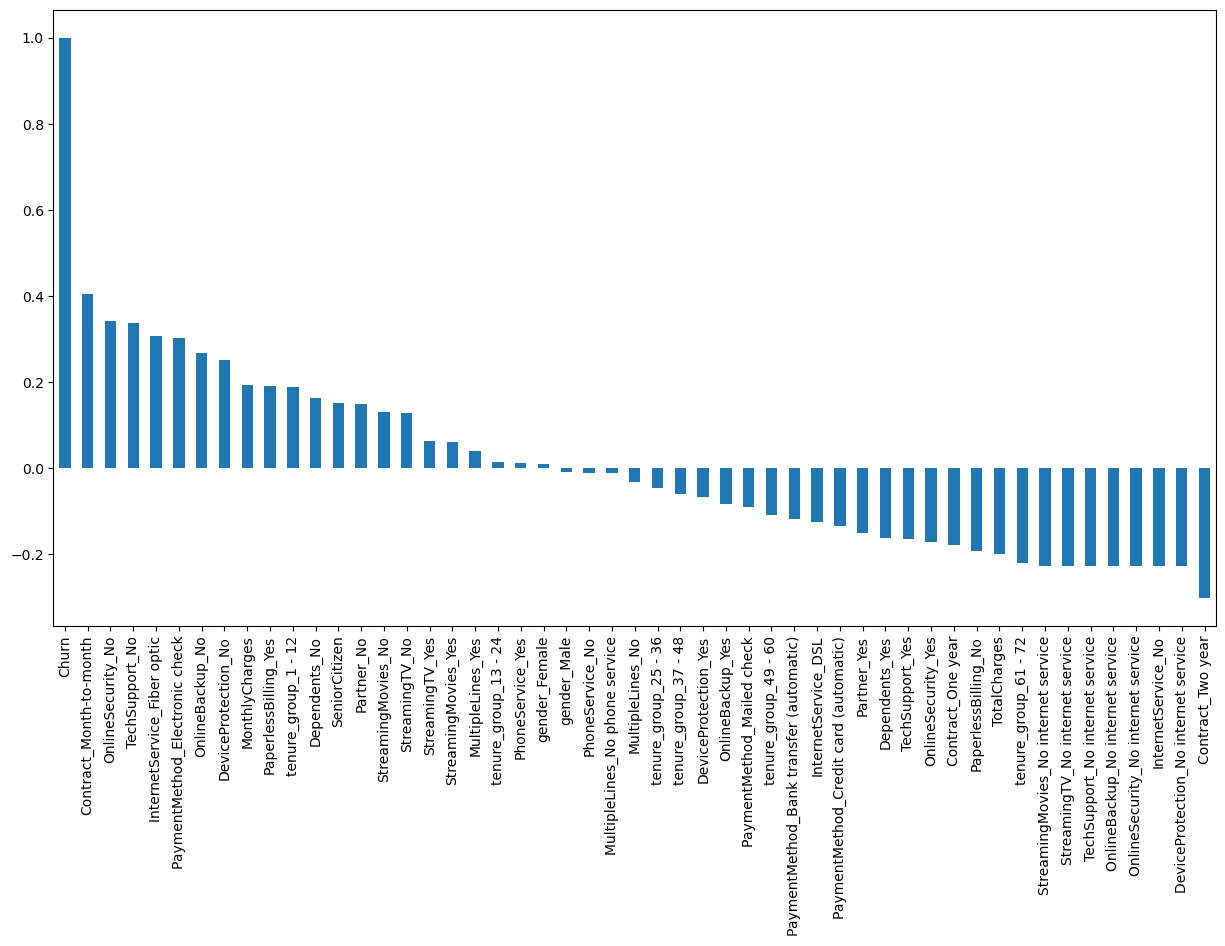

In [62]:
plt.figure(figsize=(15,8))
new_df_dummies.corr()['Churn'].sort_values(ascending=False).plot(kind='bar')

**Derived Insight**
**HIGH** Churn seen in case of **Month to Month contracts, No online security, No Tech support , First year of subscription** and **Fibre Optics Internet**

**Low** Churn is seen in case of **Long term contracts. Subscriptions without Internet service** and **The customers engaged for 5+ years**

Factors like **Gender, Availability of PhoneService** and **# of multiple lines** have almost **NO** impact on Churn

This is also evident from the **Heatmap** below

<Axes: >

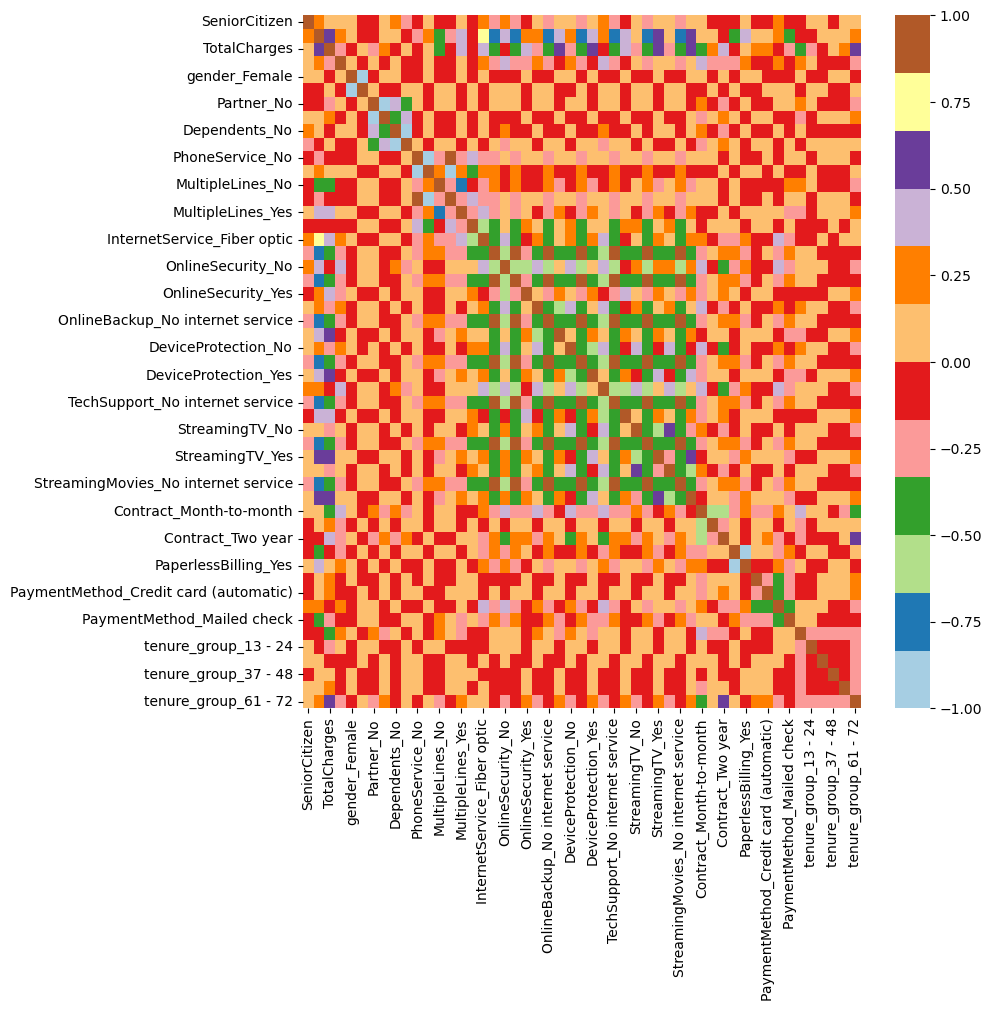

In [63]:
plt.figure(figsize=(9,9))
sns.heatmap(new_df_dummies.corr(),cmap='Paired')

In [64]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Text(0.5, 1.0, 'Tenure vs Churn')

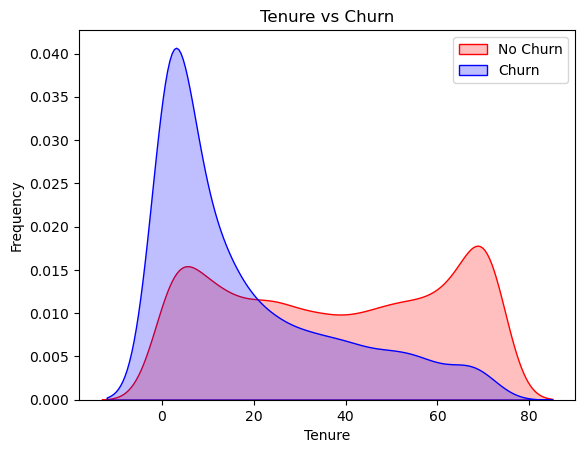

In [65]:
Tot = sns.kdeplot(df.tenure[(df["Churn"]== "No") ],
                  color = "Red", fill = True, label = "No Churn")
Tot = sns.kdeplot(df.tenure[(df["Churn"]== "Yes") ],
                  color = "Blue", fill = True, label = "Churn")
Tot.legend(["No Churn","Churn"])
Tot.set_xlabel("Tenure")
Tot.set_ylabel("Frequency")
Tot.set_title("Tenure vs Churn")

# **Bivariate Analysis**

In [66]:
new_df1_target0=new_df.loc[new_df['Churn']== 0]
new_df1_target1=new_df.loc[new_df['Churn']== 1]

In [67]:
len(new_df1_target0)

5163

In [68]:
len(new_df1_target1)

1869

In [69]:
def uniplot(df,col,title,hue = None):
  sns.set_style('whitegrid')
  sns.set_context('talk')
  plt.rcParams["axes.labelsize"] = 20
  plt.rcParams['axes.titlesize'] = 22
  plt.rcParams['axes.titlepad'] = 30

  fig, ax = plt.subplots(figsize=(10,8)) # Use a consistent figure size

  plt.xticks(rotation = 45)
  # plt.yscale('log') # Removing log scale as it's often not suitable for count plots
  plt.title(title)

  if hue:
      sns.countplot(data = df, x = col, hue = hue, order = df[col].value_counts().index, palette = 'bright', ax=ax)
  else:
      sns.countplot(data = df, x = col, order = df[col].value_counts().index, palette = 'bright', ax=ax)
  plt.tight_layout() # Add tight layout for better spacing
  plt.show()

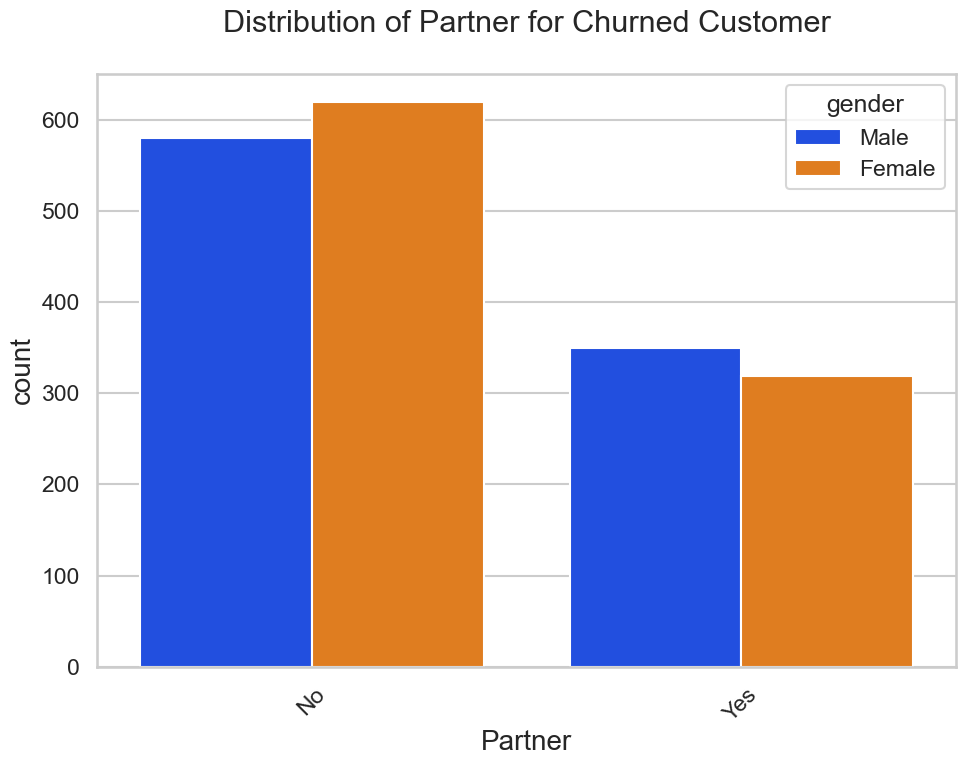

In [70]:
uniplot(new_df1_target1, col='Partner', title = 'Distribution of Partner for Churned Customer',hue ='gender')


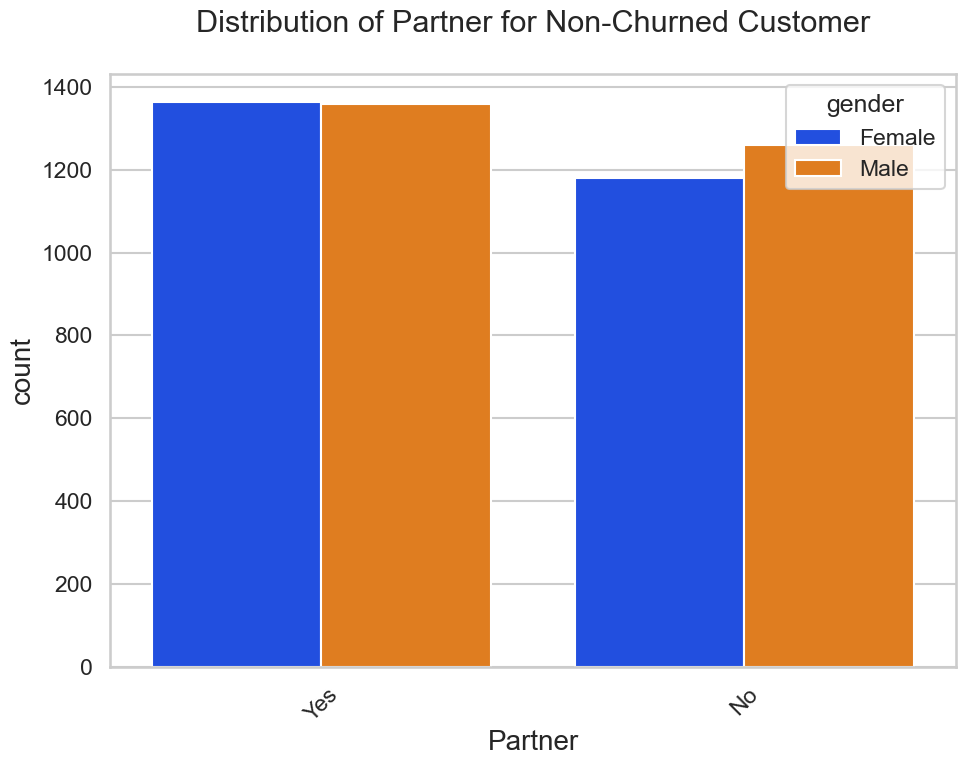

In [71]:
uniplot(new_df1_target0, col='Partner', title = 'Distribution of Partner for Non-Churned Customer',hue ='gender')


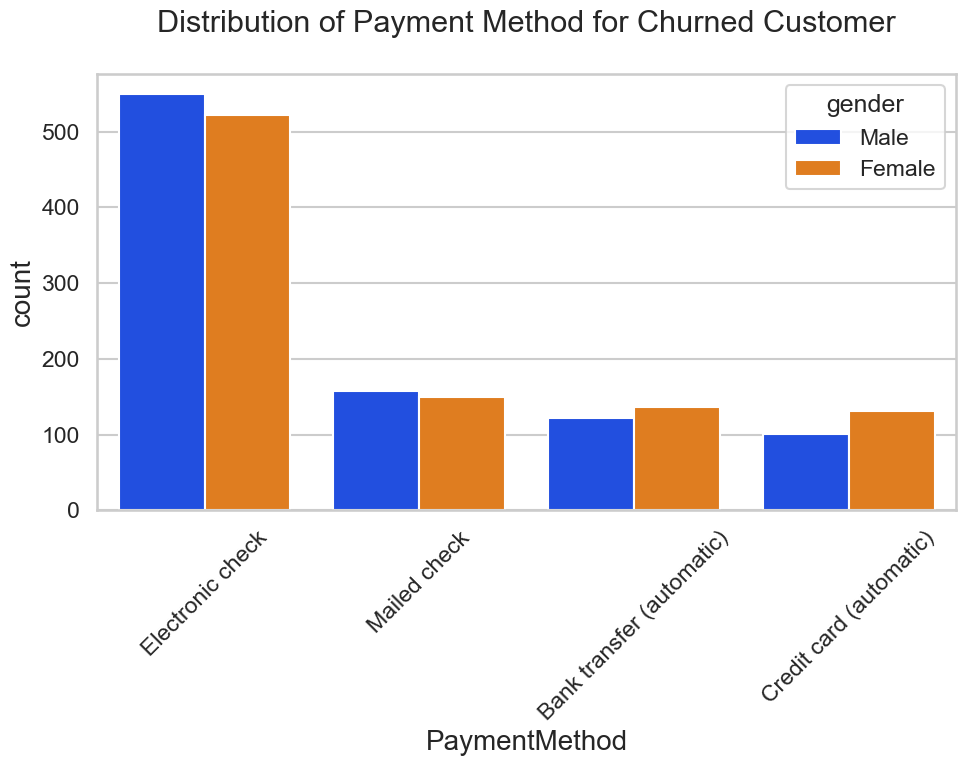

In [72]:
uniplot(new_df1_target1,col='PaymentMethod',title='Distribution of Payment Method for Churned Customer',hue='gender')

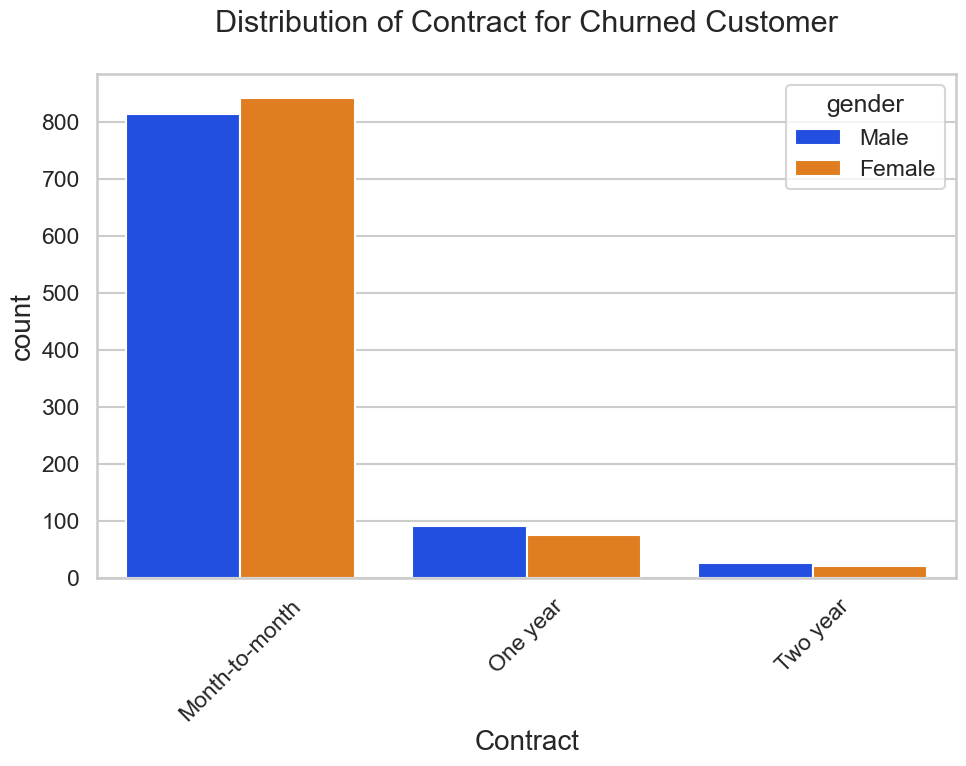

In [73]:
uniplot(new_df1_target1,col='Contract',title='Distribution of Contract for Churned Customer',hue='gender')

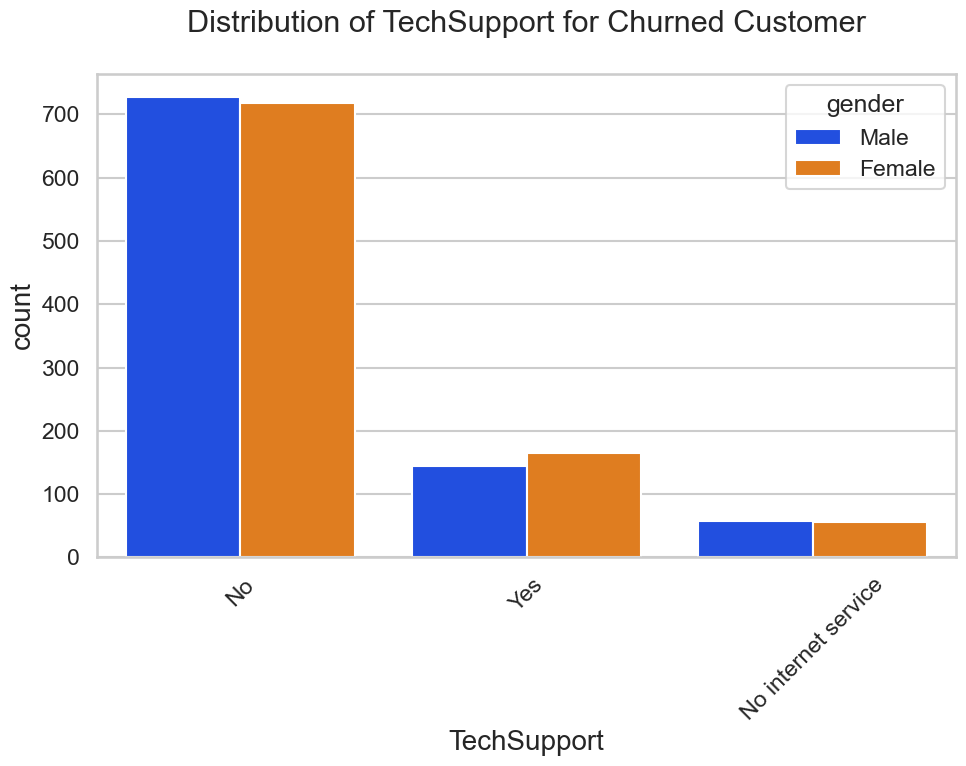

In [74]:
uniplot(new_df1_target1,col='TechSupport',title='Distribution of TechSupport for Churned Customer',hue='gender')

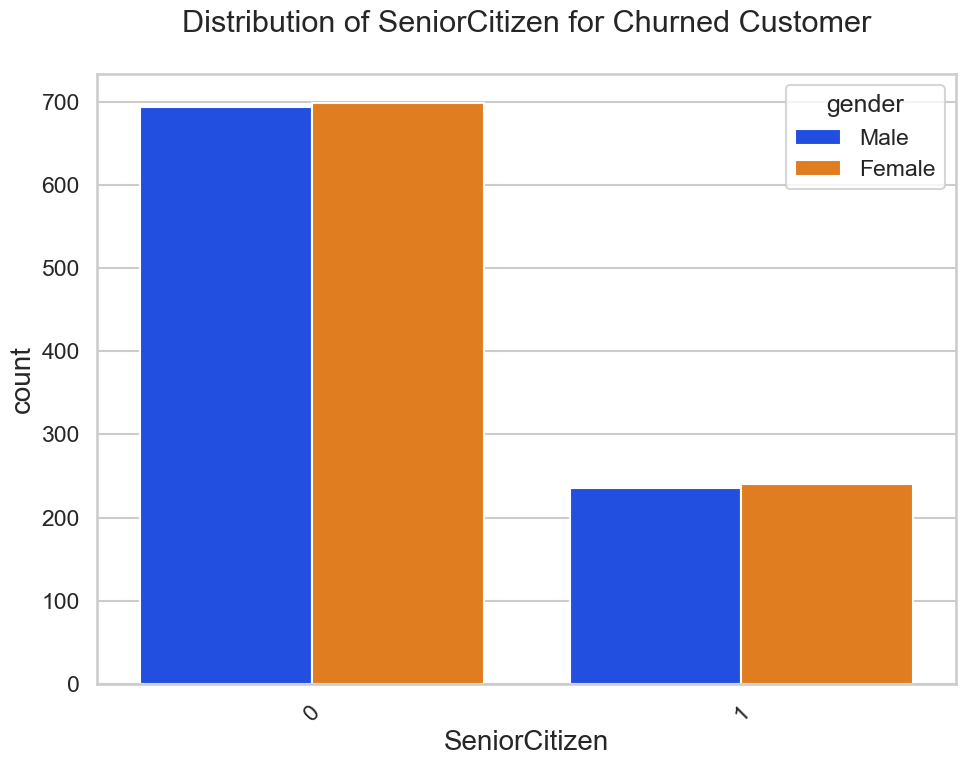

In [75]:
uniplot(new_df1_target1,col='SeniorCitizen',title='Distribution of SeniorCitizen for Churned Customer',hue='gender')

# **CONCLUSION**


These are some of the quick insights from this exercise -
- Electronic check medium are the highest churners
- No Online Security, No Tech Support category are more likely to churn because of no contract terms, as they are free to go customers.
- No Online security, No Tech Support category are high churners
- Non senior Citizens are high churners.